In [1]:
import requests

SPARQL_ENDPOINT = "https://query.wikidata.org/sparql"

query = """
SELECT ?image WHERE {
  ?item wdt:P31 wd:Q8502 .
  ?item wdt:P18 ?image .
}
LIMIT 120
"""

headers = {
    "User-Agent": "ProjetRecommendationImages/1.0"
}

response = requests.get(
    SPARQL_ENDPOINT,
    params={"query": query, "format": "json"},
    headers=headers
)

data = response.json()
results = data["results"]["bindings"]

print("Nombre d'images trouvées :", len(results))

Nombre d'images trouvées : 120


In [4]:
import os
import json
import time
import requests
from PIL import Image
from io import BytesIO

# Session avec User-Agent obligatoire
session = requests.Session()
session.headers.update({
    "User-Agent": "ProjetRecommendationImages/1.0"
})

# Fonction pour forcer téléchargement binaire Wikimedia
def to_commons_file_url(url):
    if "Special:FilePath" in url:
        return url + "?download=1"
    return url

# Téléchargement sécurisé avec gestion 429
def safe_download_image(url, max_retries=6):
    for attempt in range(max_retries):
        response = session.get(url, allow_redirects=True)

        if response.status_code == 429:
            wait_time = 2 ** attempt  # 1,2,4,8,16...
            print(f"429 reçu -> pause {wait_time}s...")
            time.sleep(wait_time)
            continue

        response.raise_for_status()

        content_type = response.headers.get("Content-Type", "").lower()
        if not content_type.startswith("image/"):
            return None

        return response.content

    return None

# Création dossiers (sécurité)
os.makedirs("images", exist_ok=True)
os.makedirs("data", exist_ok=True)

metadata_list = []
downloaded = 0
target = 100

for item in results:
    if downloaded >= target:
        break

    try:
        raw_url = item["image"]["value"]
        image_url = to_commons_file_url(raw_url)

        image_content = safe_download_image(image_url)

        if image_content is None:
            print("Image ignorée (pas valide)")
            continue

        img = Image.open(BytesIO(image_content))
        img = img.convert("RGB")

        file_name = f"image_{downloaded+1:03d}.jpg"
        file_path = os.path.join("images", file_name)

        img.save(file_path, format="JPEG", quality=90)

        width, height = img.size
        file_size = os.path.getsize(file_path) / 1024

        metadata_list.append({
            "file_name": file_name,
            "width": width,
            "height": height,
            "format": "JPEG",
            "size_kb": round(file_size, 2),
            "source_url": raw_url,
            "download_url": image_url,
            "license": "Wikimedia Commons",
            "exif": {}
        })

        downloaded += 1
        print(f"OK {downloaded}/100 -> {file_name}")

        time.sleep(1)  # important pour éviter 429

    except Exception as e:
        print("Erreur :", e)

print("Téléchargées :", downloaded)

OK 1/100 -> image_001.jpg
OK 2/100 -> image_002.jpg
429 reçu -> pause 1s...
429 reçu -> pause 2s...
429 reçu -> pause 4s...
429 reçu -> pause 8s...
429 reçu -> pause 16s...
429 reçu -> pause 32s...
Image ignorée (pas valide)
429 reçu -> pause 1s...
429 reçu -> pause 2s...
429 reçu -> pause 4s...
429 reçu -> pause 8s...
429 reçu -> pause 16s...


KeyboardInterrupt: 

In [5]:
import os
import json
import time
import requests
from PIL import Image
from io import BytesIO

os.makedirs("images", exist_ok=True)
os.makedirs("data", exist_ok=True)

session = requests.Session()
session.headers.update({"User-Agent": "ProjetRecommendationImages/1.0"})

# API Picsum : liste d'images
LIST_URL = "https://picsum.photos/v2/list?page=1&limit=200"

resp = session.get(LIST_URL, timeout=30)
resp.raise_for_status()
pics = resp.json()

metadata_list = []
downloaded = 0
target = 100

for item in pics:
    if downloaded >= target:
        break

    try:
        pic_id = item["id"]
        author = item.get("author", "")
        
        # URL directe vers une image (taille fixe)
        img_url = f"https://picsum.photos/id/{pic_id}/1200/800.jpg"
        
        r = session.get(img_url, timeout=30, allow_redirects=True)
        r.raise_for_status()

        img = Image.open(BytesIO(r.content)).convert("RGB")

        file_name = f"image_{downloaded+1:03d}.jpg"
        file_path = os.path.join("images", file_name)
        img.save(file_path, format="JPEG", quality=90)

        width, height = img.size
        size_kb = os.path.getsize(file_path) / 1024

        metadata_list.append({
            "file_name": file_name,
            "width": width,
            "height": height,
            "format": "JPEG",
            "size_kb": round(size_kb, 2),
            "source_url": item.get("url", ""),         # page Picsum
            "download_url": img_url,                  # lien téléchargement
            "license": "Picsum (photos from Unsplash)",
            "author": author,
            "exif": {}
        })

        downloaded += 1
        print(f"OK {downloaded}/100 -> {file_name}")

        time.sleep(0.2)  # petite pause (souvent pas nécessaire)

    except Exception as e:
        print("Erreur:", e)

print("Téléchargées :", downloaded)

OK 1/100 -> image_001.jpg
OK 2/100 -> image_002.jpg
OK 3/100 -> image_003.jpg
OK 4/100 -> image_004.jpg
OK 5/100 -> image_005.jpg
OK 6/100 -> image_006.jpg
OK 7/100 -> image_007.jpg
OK 8/100 -> image_008.jpg
OK 9/100 -> image_009.jpg
OK 10/100 -> image_010.jpg
OK 11/100 -> image_011.jpg
OK 12/100 -> image_012.jpg
OK 13/100 -> image_013.jpg
OK 14/100 -> image_014.jpg
OK 15/100 -> image_015.jpg
OK 16/100 -> image_016.jpg
OK 17/100 -> image_017.jpg
OK 18/100 -> image_018.jpg
OK 19/100 -> image_019.jpg
OK 20/100 -> image_020.jpg
OK 21/100 -> image_021.jpg
OK 22/100 -> image_022.jpg
OK 23/100 -> image_023.jpg
OK 24/100 -> image_024.jpg
OK 25/100 -> image_025.jpg
OK 26/100 -> image_026.jpg
OK 27/100 -> image_027.jpg
OK 28/100 -> image_028.jpg
OK 29/100 -> image_029.jpg
OK 30/100 -> image_030.jpg
OK 31/100 -> image_031.jpg
OK 32/100 -> image_032.jpg
OK 33/100 -> image_033.jpg
OK 34/100 -> image_034.jpg
OK 35/100 -> image_035.jpg
OK 36/100 -> image_036.jpg
OK 37/100 -> image_037.jpg
OK 38/100 

In [32]:
import os
import json
from PIL import Image, ExifTags

images_folder = "images"
metadata_list = []

for file_name in os.listdir(images_folder):
    if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
        file_path = os.path.join(images_folder, file_name)

        try:
            img = Image.open(file_path)

            width, height = img.size
            img_format = img.format
            file_size = os.path.getsize(file_path) / 1024

            # Extraction EXIF
            exif_data = {}
            try:
                exif_raw = img._getexif()
                if exif_raw:
                    for tag, value in exif_raw.items():
                        tag_name = ExifTags.TAGS.get(tag, tag)
                        exif_data[str(tag_name)] = str(value)
            except:
                pass

            metadata = {
                "file_name": file_name,
                "width": width,
                "height": height,
                "format": img_format,
                "size_kb": round(file_size, 2),
                "source_url": "Unknown",
                "license": "Picsum / Unsplash",
                "exif": exif_data
            }

            metadata_list.append(metadata)

        except Exception as e:
            print("Erreur sur", file_name, ":", e)

print("Images analysées :", len(metadata_list))

Images analysées : 100


In [33]:
with open("data/images_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata_list, f, indent=4, ensure_ascii=False)

print("Fichier images_metadata.json créé ✅")

Fichier images_metadata.json créé ✅


In [34]:
import os, json
import numpy as np
from PIL import Image

from sklearn.cluster import KMeans  # si erreur: pip install scikit-learn

# Palette simple pour convertir RGB -> nom (approximation)
COLOR_PALETTE = {
    "noir": (0, 0, 0),
    "blanc": (255, 255, 255),
    "gris": (128, 128, 128),
    "rouge": (220, 20, 60),
    "vert": (34, 139, 34),
    "bleu": (30, 144, 255),
    "jaune": (255, 215, 0),
    "orange": (255, 140, 0),
    "violet": (138, 43, 226),
    "rose": (255, 105, 180),
    "marron": (139, 69, 19),
    "cyan": (0, 255, 255),
}

def rgb_to_name(rgb):
    r, g, b = rgb
    best_name, best_dist = None, float("inf")
    for name, (pr, pg, pb) in COLOR_PALETTE.items():
        d = (r-pr)**2 + (g-pg)**2 + (b-pb)**2
        if d < best_dist:
            best_dist = d
            best_name = name
    return best_name

def extract_dominant_colors(image_path, k=4, max_pixels=50000):
    """
    Retourne k couleurs dominantes en RGB via KMeans.
    On downsample pour accélérer.
    """
    img = Image.open(image_path).convert("RGB")
    arr = np.array(img)

    pixels = arr.reshape(-1, 3)

    # échantillonnage pour accélérer
    if pixels.shape[0] > max_pixels:
        idx = np.random.choice(pixels.shape[0], max_pixels, replace=False)
        pixels = pixels[idx]

    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(pixels)

    centers = kmeans.cluster_centers_.astype(int)

    # Trier par fréquence (clusters les plus présents d'abord)
    labels, counts = np.unique(kmeans.labels_, return_counts=True)
    order = np.argsort(counts)[::-1]
    centers = centers[order]

    dominant = [centers[i].tolist() for i in range(min(k, len(centers)))]
    return dominant

def get_orientation(width, height, tol=0.03):
    if abs(width - height) / max(width, height) <= tol:
        return "carre"
    return "paysage" if width > height else "portrait"

def get_size_category(width, height):
    m = max(width, height)
    if m < 500:
        return "vignette"
    elif m <= 1500:
        return "moyenne"
    else:
        return "grande"

def simple_tags(dominant_colors, orientation, size_category):
    # Tags auto basiques (ça suffit pour le projet)
    names = [rgb_to_name(tuple(c)) for c in dominant_colors]
    tags = set(names)
    tags.add(orientation)
    tags.add(size_category)

    # tag luminosité simple
    # luminance approx: 0.2126R + 0.7152G + 0.0722B
    lum = np.mean([0.2126*c[0] + 0.7152*c[1] + 0.0722*c[2] for c in dominant_colors])
    if lum > 180:
        tags.add("clair")
    elif lum < 80:
        tags.add("sombre")
    else:
        tags.add("neutre")

    return sorted(tags)

In [35]:
images_folder = "images"
labels = {}

# tu peux choisir k=3,4,5 (4 est un bon compromis)
K = 4

files = sorted([f for f in os.listdir(images_folder) if f.lower().endswith((".jpg",".jpeg",".png"))])

for i, file_name in enumerate(files, start=1):
    path = os.path.join(images_folder, file_name)

    try:
        img = Image.open(path)
        width, height = img.size

        dominant = extract_dominant_colors(path, k=K)
        color_names = [rgb_to_name(tuple(c)) for c in dominant]

        orientation = get_orientation(width, height)
        size_category = get_size_category(width, height)
        tags = simple_tags(dominant, orientation, size_category)

        labels[file_name] = {
            "predominant_colors": dominant,
            "color_names": color_names,
            "orientation": orientation,
            "size_category": size_category,
            "tags": tags
        }

        if i % 10 == 0:
            print(f"OK {i}/{len(files)} : {file_name}")

    except Exception as e:
        print("Erreur sur", file_name, ":", e)

print("Images annotées :", len(labels))

OK 10/100 : image_010.jpg
OK 20/100 : image_020.png
OK 30/100 : image_030.jpg
OK 40/100 : image_040.jpg
OK 50/100 : image_050.png
OK 60/100 : image_060.jpg
OK 70/100 : image_070.jpg
OK 80/100 : image_080.png
OK 90/100 : image_090.jpg
OK 100/100 : image_100.jpg
Images annotées : 100


In [36]:
with open("data/images_labels.json", "w", encoding="utf-8") as f:
    json.dump(labels, f, indent=4, ensure_ascii=False)

print("✅ data/images_labels.json créé avec", len(labels), "images")

✅ data/images_labels.json créé avec 100 images


In [37]:
assert len(labels) >= 100, "Il faut au moins 100 images annotées"
first_key = next(iter(labels))
print("Exemple:", first_key, labels[first_key])

Exemple: image_001.jpg {'predominant_colors': [[89, 54, 43], [193, 162, 141], [152, 105, 80], [224, 221, 219]], 'color_names': ['marron', 'gris', 'gris', 'blanc'], 'orientation': 'paysage', 'size_category': 'moyenne', 'tags': ['blanc', 'gris', 'marron', 'moyenne', 'neutre', 'paysage']}


In [38]:
import json
import random
from collections import Counter

with open("data/images_labels.json", "r", encoding="utf-8") as f:
    labels = json.load(f)

all_images = list(labels.keys())
print("Nb images disponibles:", len(all_images))

Nb images disponibles: 100


In [39]:
def pick_favorites_by_preference(all_imgs, labels, prefer_colors=None, prefer_orientation=None, prefer_tags=None, n_min=10, n_max=20):
    n_fav = random.randint(n_min, n_max)

    scored = []
    for img in all_imgs:
        s = 0
        info = labels[img]

        if prefer_colors:
            s += sum(2 for c in info["color_names"] if c in prefer_colors)

        if prefer_orientation:
            s += 2 if info["orientation"] == prefer_orientation else 0

        if prefer_tags:
            s += sum(1 for t in info["tags"] if t in prefer_tags)

        scored.append((img, s))

    scored.sort(key=lambda x: x[1], reverse=True)

    # prendre surtout les meilleurs mais garder un peu de hasard
    top_pool = [img for img, _ in scored[:60]]
    favorites = random.sample(top_pool, k=min(n_fav, len(top_pool)))
    return favorites

random.seed(42)

users_raw = [
    {"user_id": "user_001", "theme": "bleu_paysage", "prefs": {"colors": ["bleu", "cyan"], "orientation": "paysage", "tags": ["clair"]}},
    {"user_id": "user_002", "theme": "vert_nature",  "prefs": {"colors": ["vert"], "orientation": "paysage", "tags": ["neutre", "clair"]}},
    {"user_id": "user_003", "theme": "sombre",       "prefs": {"colors": ["noir", "gris"], "orientation": None, "tags": ["sombre"]}},
    {"user_id": "user_004", "theme": "chaud",        "prefs": {"colors": ["rouge", "orange", "jaune"], "orientation": "portrait", "tags": ["clair", "neutre"]}},
    {"user_id": "user_005", "theme": "mix",          "prefs": {"colors": ["violet", "rose"], "orientation": None, "tags": ["neutre"]}},
]

users = []
for u in users_raw:
    favs = pick_favorites_by_preference(
        all_images, labels,
        prefer_colors=u["prefs"]["colors"],
        prefer_orientation=u["prefs"]["orientation"],
        prefer_tags=u["prefs"]["tags"]
    )
    users.append({
        "user_id": u["user_id"],
        "theme": u["theme"],
        "favorite_images": favs
    })

print("Utilisateurs simulés:", len(users))
print(users[0]["user_id"], "->", len(users[0]["favorite_images"]), "favoris")

Utilisateurs simulés: 5
user_001 -> 20 favoris


In [40]:
def build_user_profile(user, labels, top_n=3, top_tags=5):
    favs = user["favorite_images"]

    all_colors = []
    all_orientations = []
    all_sizes = []
    all_tags = []

    for img in favs:
        info = labels[img]
        all_colors.extend(info.get("color_names", []))
        all_orientations.append(info.get("orientation"))
        all_sizes.append(info.get("size_category"))
        all_tags.extend(info.get("tags", []))

    fav_colors = [c for c, _ in Counter(all_colors).most_common(top_n)]
    fav_orientation = Counter(all_orientations).most_common(1)[0][0] if all_orientations else None
    fav_size = Counter(all_sizes).most_common(1)[0][0] if all_sizes else None
    fav_tags = [t for t, _ in Counter(all_tags).most_common(top_tags)]

    return {
        "user_id": user["user_id"],
        "favorite_colors": fav_colors,
        "favorite_orientation": fav_orientation,
        "favorite_size": fav_size,
        "favorite_tags": fav_tags,
        "favorite_images": favs
    }

user_profiles = [build_user_profile(u, labels) for u in users]

print("Profil exemple :")
print(user_profiles[0])

Profil exemple :
{'user_id': 'user_001', 'favorite_colors': ['gris', 'marron', 'blanc'], 'favorite_orientation': 'paysage', 'favorite_size': 'grande', 'favorite_tags': ['gris', 'neutre', 'paysage', 'blanc', 'marron'], 'favorite_images': ['image_017.jpg', 'image_001.jpg', 'image_016.jpg', 'image_052.jpg', 'image_050.png', 'image_047.png', 'image_021.png', 'image_029.jpg', 'image_014.jpg', 'image_009.jpg', 'image_024.jpg', 'image_092.jpg', 'image_013.jpg', 'image_100.jpg', 'image_076.png', 'image_007.jpg', 'image_030.jpg', 'image_019.jpg', 'image_044.jpg', 'image_026.jpg']}


In [41]:
# Couleurs populaires globalement
global_colors = []
global_tags = []

for prof in user_profiles:
    global_colors.extend(prof["favorite_colors"])
    global_tags.extend(prof["favorite_tags"])

top_global_colors = Counter(global_colors).most_common(10)
top_global_tags = Counter(global_tags).most_common(10)

print("Top couleurs (global):", top_global_colors)
print("Top tags (global):", top_global_tags)

Top couleurs (global): [('gris', 5), ('blanc', 5), ('marron', 3), ('vert', 1), ('noir', 1)]
Top tags (global): [('gris', 5), ('neutre', 5), ('blanc', 5), ('paysage', 2), ('marron', 2), ('noir', 2), ('vert', 1), ('grande', 1), ('portrait', 1), ('carre', 1)]


In [42]:
with open("data/users.json", "w", encoding="utf-8") as f:
    json.dump(user_profiles, f, indent=4, ensure_ascii=False)

print("✅ data/users.json créé avec", len(user_profiles), "utilisateurs")

✅ data/users.json créé avec 5 utilisateurs


In [43]:
import json
import matplotlib.pyplot as plt
from collections import Counter

# Charger labels
with open("data/images_labels.json", "r", encoding="utf-8") as f:
    labels = json.load(f)

# Charger users
with open("data/users.json", "r", encoding="utf-8") as f:
    users = json.load(f)

print("Images:", len(labels))
print("Users:", len(users))

Images: 100
Users: 5


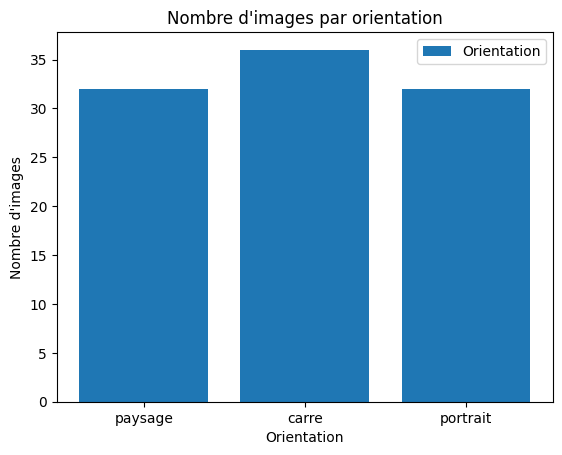

In [44]:
orientations = [info["orientation"] for info in labels.values()]
orientation_counts = Counter(orientations)

plt.figure()
plt.bar(orientation_counts.keys(), orientation_counts.values())
plt.title("Nombre d'images par orientation")
plt.xlabel("Orientation")
plt.ylabel("Nombre d'images")
plt.legend(["Orientation"])
plt.savefig("data/plot_orientation.png")
plt.show()

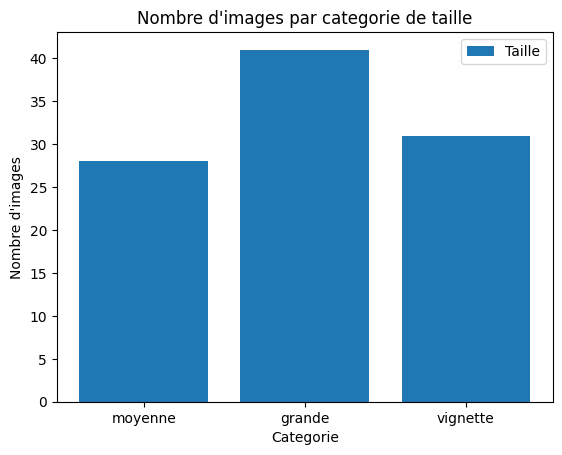

In [45]:
sizes = [info["size_category"] for info in labels.values()]
size_counts = Counter(sizes)

plt.figure()
plt.bar(size_counts.keys(), size_counts.values())
plt.title("Nombre d'images par categorie de taille")
plt.xlabel("Categorie")
plt.ylabel("Nombre d'images")
plt.legend(["Taille"])
plt.savefig("data/plot_size.png")
plt.show()

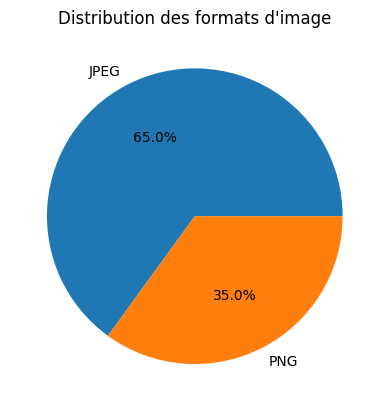

In [46]:
formats = []
for file in labels.keys():
    if file.lower().endswith(".jpg"):
        formats.append("JPEG")
    elif file.lower().endswith(".png"):
        formats.append("PNG")
    else:
        formats.append("Autre")

format_counts = Counter(formats)

plt.figure()
plt.pie(format_counts.values(), labels=format_counts.keys(), autopct='%1.1f%%')
plt.title("Distribution des formats d'image")
plt.savefig("data/plot_formats.png")
plt.show()

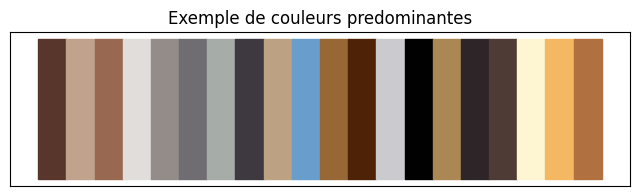

In [47]:
all_colors = []
for info in labels.values():
    all_colors.extend(info["predominant_colors"])

plt.figure(figsize=(8,2))

for i, color in enumerate(all_colors[:20]):  # afficher 20 exemples
    plt.fill_between([i, i+1], 0, 1, color=[c/255 for c in color])

plt.xticks([])
plt.yticks([])
plt.title("Exemple de couleurs predominantes")
plt.savefig("data/plot_palette.png")
plt.show()

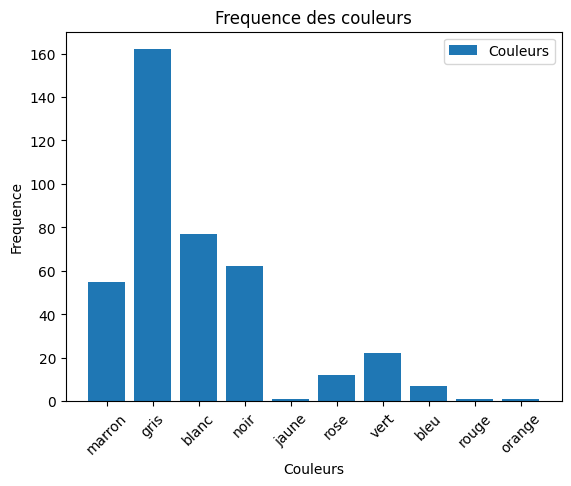

In [48]:
all_color_names = []
for info in labels.values():
    all_color_names.extend(info["color_names"])

color_counts = Counter(all_color_names)

plt.figure()
plt.bar(color_counts.keys(), color_counts.values())
plt.xticks(rotation=45)
plt.title("Frequence des couleurs")
plt.xlabel("Couleurs")
plt.ylabel("Frequence")
plt.legend(["Couleurs"])
plt.savefig("data/plot_color_histogram.png")
plt.show()

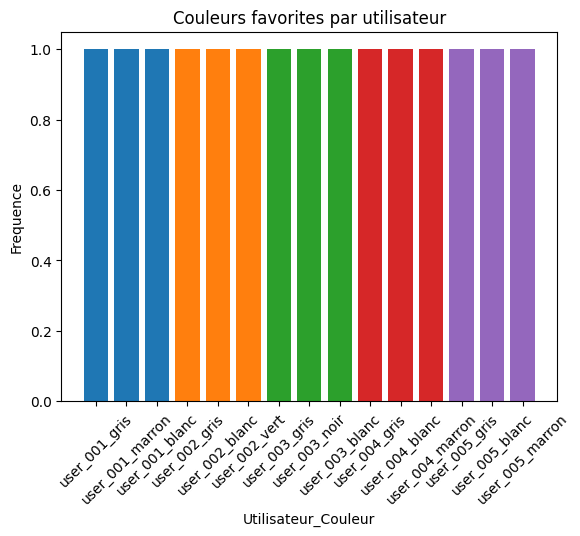

In [49]:
plt.figure()

for user in users:
    colors = user["favorite_colors"]
    counts = Counter(colors)
    plt.bar([user["user_id"] + "_" + c for c in counts.keys()],
            counts.values())

plt.xticks(rotation=45)
plt.title("Couleurs favorites par utilisateur")
plt.xlabel("Utilisateur_Couleur")
plt.ylabel("Frequence")
plt.savefig("data/plot_user_colors.png")
plt.show()

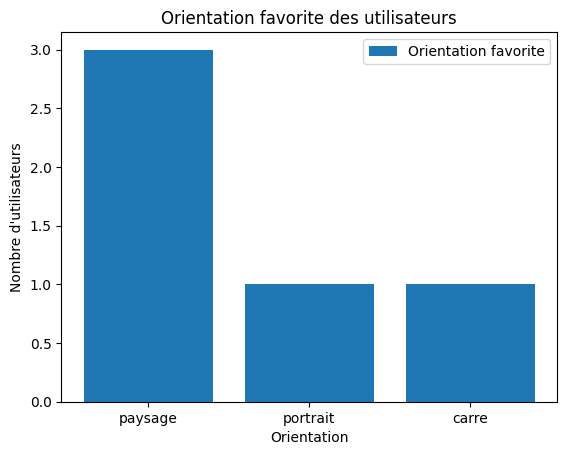

In [50]:
user_orientations = {u["user_id"]: u["favorite_orientation"] for u in users}
orientation_counts = Counter(user_orientations.values())

plt.figure()
plt.bar(orientation_counts.keys(), orientation_counts.values())
plt.title("Orientation favorite des utilisateurs")
plt.xlabel("Orientation")
plt.ylabel("Nombre d'utilisateurs")
plt.legend(["Orientation favorite"])
plt.savefig("data/plot_user_orientation.png")
plt.show()

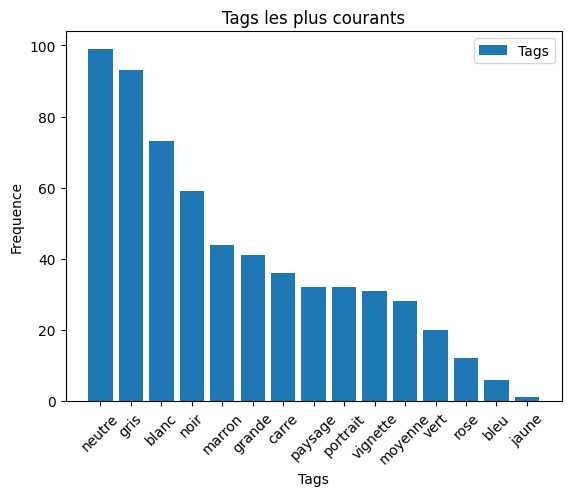

In [51]:
all_tags = []
for info in labels.values():
    all_tags.extend(info["tags"])

tag_counts = Counter(all_tags).most_common(15)

tags, counts = zip(*tag_counts)

plt.figure()
plt.bar(tags, counts)
plt.xticks(rotation=45)
plt.title("Tags les plus courants")
plt.xlabel("Tags")
plt.ylabel("Frequence")
plt.legend(["Tags"])
plt.savefig("data/plot_tags.png")
plt.show()

In [52]:
import os, random, shutil, time, json
import requests
from PIL import Image
from io import BytesIO

# ---- Réglages ----
N_IMAGES = 120          # prends 120 pour être sûr d'avoir 100+ utilisables
P_CONVERT_PNG = 0.35    # 35% en PNG, le reste en JPG
SEED = 42
random.seed(SEED)

images_dir = "images_v2"
data_dir = "data"
os.makedirs(images_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)

# 1) Nettoyer le dossier images (optionnel mais conseillé)
for f in os.listdir(images_dir):
    fp = os.path.join(images_dir, f)
    if os.path.isfile(fp):
        os.remove(fp)

session = requests.Session()
session.headers.update({"User-Agent": "ProjetRecommendationImages/1.0"})

# 2) Récup liste d'IDs picsum
pics = session.get("https://picsum.photos/v2/list?page=1&limit=500", timeout=30).json()
ids = [p["id"] for p in pics]
random.shuffle(ids)

# 3) Profils de tailles (garantit vignette/moyenne/grande)
size_profiles = [
    ("vignette_paysage", 400, 300),
    ("vignette_portrait", 300, 400),
    ("vignette_carre", 400, 400),
    ("moyenne_paysage", 1200, 800),
    ("moyenne_portrait", 800, 1200),
    ("moyenne_carre", 1000, 1000),
    ("grande_paysage", 2000, 1300),
    ("grande_portrait", 1300, 2000),
    ("grande_carre", 1800, 1800),
]

metadata_seed = []  # optionnel: on peut garder url/author ici

downloaded = 0
i = 0

while downloaded < N_IMAGES and i < len(ids):
    pic_id = ids[i]
    i += 1

    profile, w, h = random.choice(size_profiles)

    # URL jpg fixe (picsum)
    url = f"https://picsum.photos/id/{pic_id}/{w}/{h}.jpg"
    try:
        r = session.get(url, timeout=30, allow_redirects=True)
        r.raise_for_status()

        img = Image.open(BytesIO(r.content)).convert("RGB")

        # Choisir format
        make_png = (random.random() < P_CONVERT_PNG)
        ext = "png" if make_png else "jpg"
        file_name = f"image_{downloaded+1:03d}.{ext}"
        file_path = os.path.join(images_dir, file_name)

        if make_png:
            img.save(file_path, format="PNG", optimize=True)
        else:
            img.save(file_path, format="JPEG", quality=90)

        metadata_seed.append({
            "file_name": file_name,
            "download_url": url,
            "source_url": f"https://picsum.photos/id/{pic_id}",
            "license": "Picsum (photos from Unsplash)",
            "generation_profile": profile
        })

        downloaded += 1
        print(f"OK {downloaded}/{N_IMAGES} -> {file_name} ({profile})")
        time.sleep(0.1)

    except Exception as e:
        print("Erreur:", pic_id, e)

print("✅ Total images générées:", downloaded)

OK 1/120 -> image_001.jpg (moyenne_paysage)
OK 2/120 -> image_002.png (moyenne_carre)
OK 3/120 -> image_003.jpg (grande_portrait)
OK 4/120 -> image_004.png (grande_portrait)
OK 5/120 -> image_005.png (vignette_carre)
OK 6/120 -> image_006.jpg (grande_carre)
OK 7/120 -> image_007.jpg (grande_paysage)
OK 8/120 -> image_008.jpg (grande_paysage)
OK 9/120 -> image_009.jpg (vignette_carre)
OK 10/120 -> image_010.jpg (vignette_portrait)
OK 11/120 -> image_011.png (vignette_portrait)
OK 12/120 -> image_012.jpg (vignette_carre)
OK 13/120 -> image_013.jpg (grande_paysage)
OK 14/120 -> image_014.jpg (grande_paysage)
OK 15/120 -> image_015.jpg (grande_portrait)
OK 16/120 -> image_016.jpg (grande_carre)
OK 17/120 -> image_017.jpg (vignette_paysage)
OK 18/120 -> image_018.jpg (vignette_portrait)
OK 19/120 -> image_019.jpg (grande_carre)
OK 20/120 -> image_020.png (moyenne_carre)
OK 21/120 -> image_021.png (grande_paysage)
OK 22/120 -> image_022.jpg (vignette_paysage)
OK 23/120 -> image_023.jpg (moye

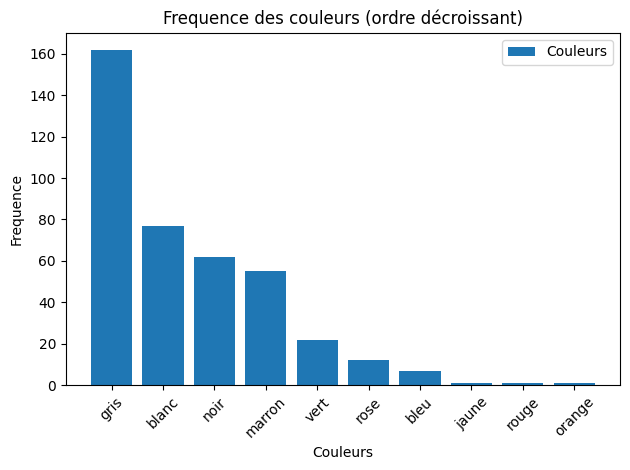

In [55]:
from collections import Counter
import matplotlib.pyplot as plt

all_color_names = []
for info in labels.values():
    all_color_names.extend(info["color_names"])

color_counts = Counter(all_color_names)

# 🔥 TRI DÉCROISSANT
sorted_colors = sorted(color_counts.items(), key=lambda x: x[1], reverse=True)

colors, counts = zip(*sorted_colors)

plt.figure()
plt.bar(colors, counts)
plt.xticks(rotation=45)
plt.title("Frequence des couleurs (ordre décroissant)")
plt.xlabel("Couleurs")
plt.ylabel("Frequence")
plt.legend(["Couleurs"])
plt.savefig("data/plot_color_histogram.png")
plt.tight_layout()
plt.show()
